In [1]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:

# Define paths
zip_path = "/content/drive/My Drive/archive (8).zip"  # Change this
extract_path = "/content/unzipped_folder"  # Destination folder in Colab

# Create extraction directory
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List extracted files
print("Unzipping done! Extracted files:")
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))



Streaming output truncated to the last 5000 lines.
/content/unzipped_folder/Negative/13479.jpg
/content/unzipped_folder/Negative/16091.jpg
/content/unzipped_folder/Negative/02250.jpg
/content/unzipped_folder/Negative/00883.jpg
/content/unzipped_folder/Negative/08340.jpg
/content/unzipped_folder/Negative/03126.jpg
/content/unzipped_folder/Negative/08971.jpg
/content/unzipped_folder/Negative/16978.jpg
/content/unzipped_folder/Negative/06896.jpg
/content/unzipped_folder/Negative/18159.jpg
/content/unzipped_folder/Negative/19459.jpg
/content/unzipped_folder/Negative/14282.jpg
/content/unzipped_folder/Negative/04860.jpg
/content/unzipped_folder/Negative/00130.jpg
/content/unzipped_folder/Negative/15108.jpg
/content/unzipped_folder/Negative/18839.jpg
/content/unzipped_folder/Negative/00241.jpg
/content/unzipped_folder/Negative/18465.jpg
/content/unzipped_folder/Negative/08221.jpg
/content/unzipped_folder/Negative/19023.jpg
/content/unzipped_folder/Negative/14923.jpg
/content/unzipped_folder/

Found 32000 images belonging to 2 classes.
Found 8000 images belonging to 2 classes.


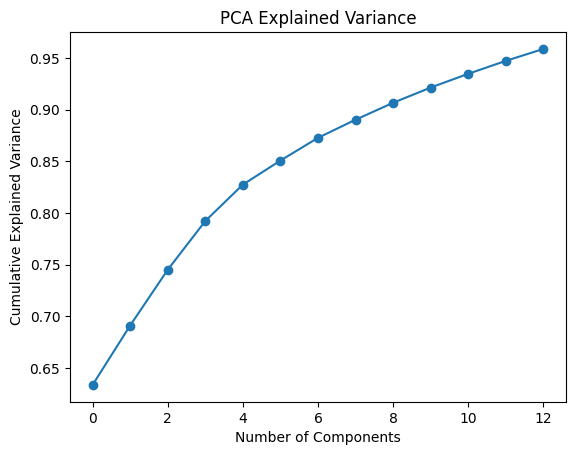

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:18:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:18:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:18:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:18:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:18:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

XGBoost Average Accuracy: 70.00%
Random Forest Average Accuracy: 87.62%
Final Model Accuracy: 90.62%
True Positives (TP): 10
True Negatives (TN): 19
False Positives (FP): 0
False Negatives (FN): 3


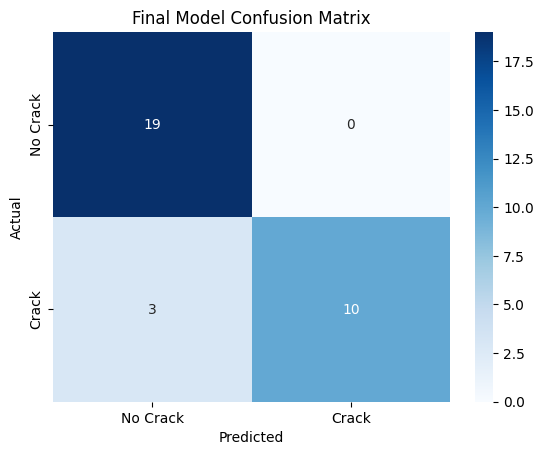

In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Define paths
base_dir = '/content/unzipped_folder'  # Update if necessary
positive_dir = os.path.join(base_dir, 'positive')  # Cracks present
negative_dir = os.path.join(base_dir, 'negative')  # No cracks

# Image parameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Data Augmentation
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2, rotation_range=20,
                                   width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2,
                                   zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

# Extract features and labels
X_train, y_train = next(train_generator)
X_val, y_val = next(val_generator)

# Flatten images for PCA analysis
X_train_flattened = X_train.reshape(X_train.shape[0], -1)
X_val_flattened = X_val.reshape(X_val.shape[0], -1)

# PCA Analysis
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_flattened)
X_val_pca = pca.transform(X_val_flattened)

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

# Normalize Data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)
X_val_scaled = scaler.transform(X_val_pca)

# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Label Encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_resampled)
y_val_encoded = label_encoder.transform(y_val)

# Define classifiers
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Stratified K-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_accuracies = []
rf_accuracies = []

for train_index, test_index in skf.split(X_train_resampled, y_train_encoded):
    X_train_fold, X_test_fold = X_train_resampled[train_index], X_train_resampled[test_index]
    y_train_fold, y_test_fold = y_train_encoded[train_index], y_train_encoded[test_index]

    # Train and evaluate XGBoost
    xgb_clf.fit(X_train_fold, y_train_fold)
    y_pred_xgb = xgb_clf.predict(X_test_fold)
    xgb_accuracies.append(accuracy_score(y_test_fold, y_pred_xgb))

    # Train and evaluate Random Forest
    rf_clf.fit(X_train_fold, y_train_fold)
    y_pred_rf = rf_clf.predict(X_test_fold)
    rf_accuracies.append(accuracy_score(y_test_fold, y_pred_rf))

# Compute average accuracy
print(f"XGBoost Average Accuracy: {np.mean(xgb_accuracies) * 100:.2f}%")
print(f"Random Forest Average Accuracy: {np.mean(rf_accuracies) * 100:.2f}%")

# Predict on validation set using the best model (XGBoost)
y_pred_final = xgb_clf.predict(X_val_scaled)

# Evaluate final model
accuracy_final = accuracy_score(y_val_encoded, y_pred_final) * 100
print(f"Final Model Accuracy: {accuracy_final:.2f}%")

# Compute Confusion Matrix
conf_matrix_final = confusion_matrix(y_val_encoded, y_pred_final)
tn, fp, fn, tp = conf_matrix_final.ravel()  # Extract TP, TN, FP, FN

print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

sns.heatmap(conf_matrix_final, annot=True, fmt='d', cmap='Blues', xticklabels=['No Crack', 'Crack'], yticklabels=['No Crack', 'Crack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Model Confusion Matrix')
plt.show()
